# **K-Nearest Neighbors and Decision Trees for Iris Classification**

## **Objective**  
Train and evaluate **K-Nearest Neighbors (KNN)** models to classify Iris species based on features like petal length, petal width, sepal length, and sepal width.

---

## **Dataset**  
Use the **Iris dataset** from `sklearn.datasets`. Load it into a Pandas DataFrame and display the first few rows.

---

## **Tasks**  

### **1. Data Preprocessing**  
- Load the **Iris dataset** and check for missing values.  
- Split the dataset into **80% training and 20% testing**.  
- Standardize the features using **StandardScaler**.  

---

### **2. Train K-Nearest Neighbors (KNN) Model**  
- Train a **K-Nearest Neighbors classifier** with the default parameters (use `KNeighborsClassifier` from `sklearn`).  
- Evaluate the model’s performance using accuracy.  
- Experiment with different values of `k` (e.g., 3, 5, 7) and analyze the performance.  

---


### **3. Model Evaluation**  
- Compute and print the following metrics for KNN:  
  - **Accuracy**  
  - **Precision**  
  - **Recall**  
  - **F1-Score**  
  - **Confusion Matrix**  

---

### **4. Visualization**  
- Plot the **Confusion Matrix** for both models to evaluate performance.

---



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)

#Q1

iris = load_iris()
X = iris.data
y = iris.target

feature_names = iris.feature_names
target_names = iris.target_names


In [ ]:
feature_names = iris.feature_names
print(feature_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [ ]:
#Loading Data
df = pd.DataFrame(X, columns=feature_names)
df["species"] = y


In [ ]:
print("5 rows of dataset:")
print(df.head())

5 rows of dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  


In [ ]:
print("\nMissing values:")
print(df.isnull().sum())


Missing values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


In [ ]:
#Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
#Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
#Q2 + Q3

k_list = [3, 5, 7]
print("\nAccuracy for different k:")
for k in k_list:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    print(f"K = {k}: Accuracy = {acc:.2f}")

#Displaying only one KNN's rest of Evaluations (k=5)
knn_5 = KNeighborsClassifier()
knn_5.fit(X_train_scaled, y_train)
y_pred_5 = knn_5.predict(X_test_scaled)


print("\nAccuracy:", accuracy_score(y_test, y_pred_5))
print("Precision", precision_score(y_test, y_pred_5, average='micro'))
print("Recall", recall_score(y_test, y_pred_5, average='micro'))
print("F1-Score", f1_score(y_test, y_pred_5, average='micro'))




Accuracy for different k:
K = 3: Accuracy = 1.00
K = 5: Accuracy = 1.00
K = 7: Accuracy = 1.00

Accuracy: 1.0
Precision 1.0
Recall 1.0
F1-Score 1.0



Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


<Figure size 600x500 with 0 Axes>

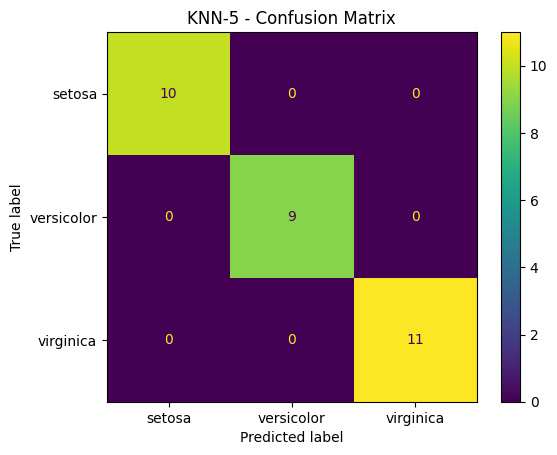

In [ ]:
#Q4

cm = confusion_matrix(y_test, y_pred_5)
print("\nConfusion Matrix:\n", cm)

plt.figure(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_5, display_labels=target_names)
plt.title("KNN-5 - Confusion Matrix")
plt.show()


# Simple KNN Code:

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

#Train
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

#Predict
y_pred_knn = knn.predict(X_test_scaled)

# Simple Decision Trees

In [ ]:
# Simple Decision Tree Classifier

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

#Training Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

#Predict
y_pred_dt = dt.predict(X_test)

#Evaluate
print("\n Decision Tree Evaluation")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt, average='macro'))
print("Recall:", recall_score(y_test, y_pred_dt, average='macro'))
print("F1-Score:", f1_score(y_test, y_pred_dt, average='macro'))



 Decision Tree Evaluation
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-Score: 1.0
